# I. Identificación del proyecto
## Supervivencia en el Titanic: exploración de factores asociados a la supervivencia
### Evaluación Sumativa S01 — Implementación inicial del EDA reproducible

**Asignatura:** MCDI503 — Exploración Inteligente de Datos  
**Integrantes:** Luis Díaz · Gonzalo Bouldres · Eduardo Contreras  
**Fecha de versión:** 06/09/2026  
**Dataset:** `titanic` distribuido por Seaborn, con copia local auditada en `data/input/titanic_seaborn.csv`

### Propósito general
Implementar un primer ciclo de análisis exploratorio de datos reproducible sobre el conjunto `titanic`, integrando carga controlada, diagnóstico de calidad, análisis descriptivo, transformaciones derivadas, visualizaciones y documentación trazable. El notebook organiza el trabajo mediante la secuencia **pregunta → acción → resultado → evidencia**, de modo que las interpretaciones se generen únicamente a partir de la ejecución.

# II. Contexto y objetivo exploratorio
El proyecto examina la supervivencia de los pasajeros del Titanic y su comportamiento descriptivo respecto de características demográficas y del viaje. Antes de aplicar procedimientos inferenciales o predictivos, se caracteriza la calidad de los datos y se documentan las decisiones adoptadas durante la exploración.

### Objetivo exploratorio
Describir la supervivencia de los pasajeros y analizar patrones asociados con sexo, clase, edad, tarifa y tamaño del grupo familiar, considerando las condiciones de calidad que puedan limitar la interpretación.

### Preguntas exploratorias
1. ¿Cuál es la proporción de supervivencia y cómo cambia según sexo?
2. ¿Existen diferencias de supervivencia entre las clases de pasajero?
3. ¿Cómo se distribuye `age` y qué diferencias descriptivas aparecen entre sobrevivientes y no sobrevivientes, considerando sus valores faltantes?
4. ¿Cómo se comporta `fare` y qué patrones preliminares presenta respecto de clase y supervivencia?
5. ¿El tamaño del grupo familiar, derivado de `sibsp` y `parch`, presenta diferencias descriptivas de supervivencia que convenga profundizar?

### Alcance y supuestos iniciales
- El análisis corresponde a un EDA descriptivo univariado y bivariado.
- `survived` se interpreta como variable binaria y `pclass` como variable ordinal categórica.
- Los valores faltantes y observaciones extremas se identifican antes de adoptar decisiones de tratamiento.
- En esta fase no se realizan imputaciones, pruebas inferenciales ni modelos predictivos.
- Las asociaciones observadas se interpretan de manera descriptiva y no causal.

### Organización reproducible del proyecto
```text
├── data/
│   ├── input/        # insumo original auditado
│   └── process/      # generado por código
├── figures/          # generado por código
├── notebooks/        # notebook principal
├── outputs/          # tablas, manifiesto y síntesis generados por código
├── Reports/          # reservado para el informe complementario
├── requirements.txt
├── environment.yml
└── README.md
```

La secuencia de trabajo es: **carga e integridad → estructura y calidad → descriptivos → preguntas exploratorias → transformaciones → visualizaciones → trazabilidad → síntesis → validación de coherencia**.

In [1]:
from pathlib import Path
from datetime import datetime
import hashlib
import sys
import shutil
from importlib.metadata import version as package_version, PackageNotFoundError

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

EXPECTED_SHA256 = "43af81a01f25a7771c9a42809a31625f4d0de3f335cdf29961f9ba179a86c13d"
EXPECTED_INPUT_SHAPE = (891, 15)


def version_paquete(nombre):
    try:
        return package_version(nombre)
    except PackageNotFoundError:
        return "no instalado"


def localizar_raiz_proyecto(inicio=None):
    """Localiza la raíz del proyecto para permitir ejecución desde raíz o notebooks/."""
    inicio = (inicio or Path.cwd()).resolve()
    for candidato in [inicio, *inicio.parents]:
        if (candidato / "data").exists() and (candidato / "notebooks").exists():
            return candidato
    if inicio.name == "notebooks":
        return inicio.parent
    return inicio


BASE_DIR = localizar_raiz_proyecto()
INPUT_DIR = BASE_DIR / "data" / "input"
PROCESS_DIR = BASE_DIR / "data" / "process"
FIGURES_DIR = BASE_DIR / "figures"
OUTPUTS_DIR = BASE_DIR / "outputs"
REPORTS_DIR = BASE_DIR / "Reports"

for d in [INPUT_DIR, PROCESS_DIR, FIGURES_DIR, OUTPUTS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Se eliminan únicamente productos derivados para garantizar una corrida reproducible.
# El archivo de entrada y la carpeta Reports/ permanecen intactos.
for d in [PROCESS_DIR, FIGURES_DIR, OUTPUTS_DIR]:
    for item in d.iterdir():
        if item.is_dir():
            shutil.rmtree(item)
        else:
            item.unlink()

print("Productos derivados previos eliminados: data/process, figures y outputs.")
print(f"Raíz del proyecto: {BASE_DIR}")
print(f"Python: {sys.version.split()[0]}")
print(
    f"pandas: {pd.__version__} | numpy: {np.__version__} | "
    f"seaborn: {sns.__version__} | matplotlib: {plt.matplotlib.__version__}"
)
print(
    f"ipykernel: {version_paquete('ipykernel')} | notebook: {version_paquete('notebook')} | "
    f"jupyterlab: {version_paquete('jupyterlab')}"
)

Productos derivados previos eliminados: data/process, figures y outputs.
Raíz del proyecto: ./
Python: 3.12.4
pandas: 2.2.2 | numpy: 1.26.4 | seaborn: 0.13.2 | matplotlib: 3.8.4
ipykernel: 6.28.0 | notebook: 7.0.8 | jupyterlab: 4.0.11


# III. Carga y revisión inicial de datos
## 3.1 Carga controlada e integridad de la fuente
Se utiliza exclusivamente la copia local auditada del dataset `titanic` distribuido por Seaborn. El archivo de entrada no se modifica durante el análisis. Antes de continuar se verifica su identidad mediante SHA-256 y sus dimensiones contra la referencia registrada del proyecto.

In [2]:
DATA_PATH = INPUT_DIR / "titanic_seaborn.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Falta el insumo obligatorio data/input/titanic_seaborn.csv. "
        "La corrida definitiva no descarga datos desde Internet."
    )

raw = pd.read_csv(DATA_PATH)
fuente_datos = "Copia local auditada del dataset Titanic distribuido por Seaborn"
sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()

if sha256 != EXPECTED_SHA256:
    raise ValueError(
        "La integridad del archivo de entrada no coincide con la versión auditada. "
        f"SHA-256 obtenido: {sha256}"
    )

if tuple(raw.shape) != EXPECTED_INPUT_SHAPE:
    raise ValueError(
        f"Dimensiones inesperadas del dataset: {raw.shape}; "
        f"se esperaba {EXPECTED_INPUT_SHAPE}."
    )

titanic = raw.copy()

print(f"Fuente: {fuente_datos}")
print(f"Archivo local: {DATA_PATH.relative_to(BASE_DIR).as_posix()}")
print(f"SHA-256: {sha256} [OK]")
print(f"Dimensiones: {titanic.shape[0]} filas x {titanic.shape[1]} columnas [OK]")
display(titanic.head())


Fuente: Copia local auditada del dataset Titanic distribuido por Seaborn
Archivo local: data/input/titanic_seaborn.csv
SHA-256: 43af81a01f25a7771c9a42809a31625f4d0de3f335cdf29961f9ba179a86c13d [OK]
Dimensiones: 891 filas x 15 columnas [OK]


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000,1,0,7.250,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.000,1,0,71.283,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000,0,0,7.925,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.000,1,0,53.100,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000,0,0,8.050,S,Third,man,True,NaN,Southampton,no,True


## 3.2 Estructura, tipos y calidad inicial
Se revisan tipos de datos, roles analíticos, valores faltantes, cardinalidad, filas completamente coincidentes, rangos numéricos y categorías observadas. El objetivo es caracterizar el estado inicial del conjunto antes de cualquier transformación o tratamiento.

In [3]:
rol_por_variable = {
    "survived": "binaria (variable objetivo exploratoria)",
    "pclass": "ordinal categórica",
    "sex": "nominal",
    "age": "numérica continua",
    "sibsp": "numérica discreta",
    "parch": "numérica discreta",
    "fare": "numérica continua",
    "embarked": "nominal",
    "class": "ordinal categórica",
    "who": "nominal derivada",
    "adult_male": "binaria",
    "deck": "categórica con alta ausencia",
    "embark_town": "nominal",
    "alive": "categórica derivada de survived",
    "alone": "binaria derivada"
}

roles = pd.DataFrame({
    "variable": titanic.columns,
    "tipo_python": [str(t) for t in titanic.dtypes],
    "rol_analitico": [rol_por_variable.get(col, "por revisar") for col in titanic.columns]
})

calidad = pd.DataFrame({
    "tipo": titanic.dtypes.astype(str),
    "nulos": titanic.isna().sum(),
    "nulos_pct": (titanic.isna().mean() * 100).round(2),
    "unicos": titanic.nunique(dropna=True)
}).sort_values("nulos_pct", ascending=False)

numeric_cols = titanic.select_dtypes(include=[np.number]).columns
rangos_numericos = pd.DataFrame({
    "variable": numeric_cols,
    "minimo": [titanic[c].min() for c in numeric_cols],
    "maximo": [titanic[c].max() for c in numeric_cols],
    "mediana": [titanic[c].median() for c in numeric_cols],
})

categorical_cols = titanic.select_dtypes(exclude=[np.number]).columns
categorias_observadas = pd.DataFrame([
    {
        "variable": col,
        "n_categorias_validas": titanic[col].nunique(dropna=True),
        "categorias_observadas": " | ".join(sorted(map(str, titanic[col].dropna().unique())))
    }
    for col in categorical_cols
])

duplicados = int(titanic.duplicated().sum())
print(f"Filas completamente coincidentes en las variables disponibles: {duplicados}")
display(roles)
display(calidad)
display(rangos_numericos.round(3))
display(categorias_observadas)

calidad.to_csv(OUTPUTS_DIR / "resumen_calidad.csv", encoding="utf-8", index_label="variable")
rangos_numericos.to_csv(OUTPUTS_DIR / "rangos_numericos.csv", index=False, encoding="utf-8")
categorias_observadas.to_csv(OUTPUTS_DIR / "categorias_observadas.csv", index=False, encoding="utf-8")

faltantes = calidad[calidad["nulos"] > 0]
if faltantes.empty:
    texto_faltantes = "No se identificaron valores faltantes en las variables revisadas."
else:
    detalle = "; ".join(
        f"`{idx}`: {int(row['nulos'])} ({row['nulos_pct']:.1f} %)"
        for idx, row in faltantes.iterrows()
    )
    texto_faltantes = f"Las variables con valores faltantes son: {detalle}."

if duplicados == 0:
    texto_dup = "No se identificaron filas completamente coincidentes."
else:
    texto_dup = (
        f"Se identificaron **{duplicados} filas completamente coincidentes** considerando todas las variables disponibles. "
        "Dado que esta versión del dataset no contiene un identificador individual único, estas coincidencias se documentan "
        "y no se eliminan automáticamente."
    )

display(Markdown(
    "### Lectura de la revisión inicial\n"
    + texto_faltantes + "\n\n"
    + texto_dup + "\n\n"
    + "Los rangos numéricos, la cardinalidad y las categorías observadas quedan documentados en las tablas anteriores. "
      "En esta fase los faltantes y valores atípicos se caracterizan antes de adoptar cualquier tratamiento."
))


Filas completamente coincidentes en las variables disponibles: 107


,variable,tipo_python,rol_analitico
0,survived,int64,binaria (variable objetivo exploratoria)
1,pclass,int64,ordinal categórica
2,sex,object,nominal
3,age,float64,numérica continua
4,sibsp,int64,numérica discreta
5,parch,int64,numérica discreta
6,fare,float64,numérica continua
7,embarked,object,nominal
8,class,object,ordinal categórica
9,who,object,nominal derivada


,tipo,nulos,nulos_pct,unicos
deck,object,688,77.220,7
age,float64,177,19.870,88
embarked,object,2,0.220,3
embark_town,object,2,0.220,3
survived,int64,0,0.000,2
pclass,int64,0,0.000,3
sex,object,0,0.000,2
sibsp,int64,0,0.000,7
parch,int64,0,0.000,7
fare,float64,0,0.000,248


,variable,minimo,maximo,mediana
0,survived,0.000,1.000,0.000
1,pclass,1.000,3.000,3.000
2,age,0.420,80.000,28.000
3,sibsp,0.000,8.000,0.000
4,parch,0.000,6.000,0.000
5,fare,0.000,512.329,14.454


,variable,n_categorias_validas,categorias_observadas
0,sex,2,female | male
1,embarked,3,C | Q | S
2,class,3,First | Second | Third
3,who,3,child | man | woman
4,adult_male,2,False | True
5,deck,7,A | B | C | D | E | F | G
6,embark_town,3,Cherbourg | Queenstown | Southampton
7,alive,2,no | yes
8,alone,2,False | True


### Lectura de la revisión inicial
Las variables con valores faltantes son: `deck`: 688 (77.2 %); `age`: 177 (19.9 %); `embarked`: 2 (0.2 %); `embark_town`: 2 (0.2 %).

Se identificaron **107 filas completamente coincidentes** considerando todas las variables disponibles. Dado que esta versión del dataset no contiene un identificador individual único, estas coincidencias se documentan y no se eliminan automáticamente.

Los rangos numéricos, la cardinalidad y las categorías observadas quedan documentados en las tablas anteriores. En esta fase los faltantes y valores atípicos se caracterizan antes de adoptar cualquier tratamiento.

## 3.3 Diagnóstico gráfico inicial
Se generan visualizaciones de valores faltantes y distribuciones de variables relevantes para complementar la caracterización tabular del dataset.

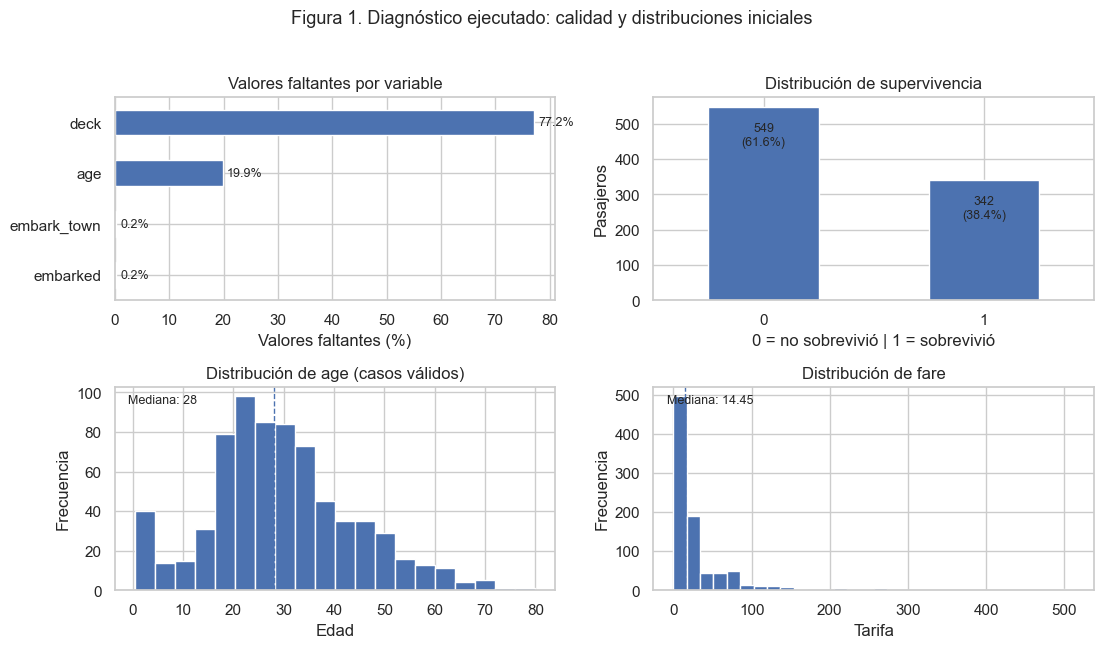

In [4]:
# Figura 1. Diagnóstico de calidad y distribuciones iniciales
missing = (titanic.isna().mean()*100).sort_values(ascending=False)
missing_nonzero = missing[missing > 0].sort_values()

fig, axes = plt.subplots(2, 2, figsize=(11.2, 6.6))

missing_nonzero.plot(kind="barh", ax=axes[0,0])
axes[0,0].set_title("Valores faltantes por variable")
axes[0,0].set_xlabel("Valores faltantes (%)")
axes[0,0].set_ylabel("")
for i, v in enumerate(missing_nonzero):
    axes[0,0].text(v + 0.8, i, f"{v:.1f}%", va="center", fontsize=9)

counts = titanic["survived"].value_counts().sort_index()
counts.plot(kind="bar", ax=axes[0,1], rot=0)
axes[0,1].set_title("Distribución de supervivencia")
axes[0,1].set_xlabel("0 = no sobrevivió | 1 = sobrevivió")
axes[0,1].set_ylabel("Pasajeros")
for i, v in enumerate(counts.values):
    axes[0,1].text(i, v - 45, f"{v}\n({v/len(titanic)*100:.1f}%)", ha="center", va="top", fontsize=9)

axes[1,0].hist(titanic["age"].dropna(), bins=20)
axes[1,0].axvline(titanic["age"].median(), linestyle="--", linewidth=1)
axes[1,0].set_title("Distribución de age (casos válidos)")
axes[1,0].set_xlabel("Edad")
axes[1,0].set_ylabel("Frecuencia")
axes[1,0].text(0.03, 0.92, f"Mediana: {titanic['age'].median():.0f}", transform=axes[1,0].transAxes, fontsize=9)

axes[1,1].hist(titanic["fare"].dropna(), bins=30)
axes[1,1].axvline(titanic["fare"].median(), linestyle="--", linewidth=1)
axes[1,1].set_title("Distribución de fare")
axes[1,1].set_xlabel("Tarifa")
axes[1,1].set_ylabel("Frecuencia")
axes[1,1].text(0.03, 0.92, f"Mediana: {titanic['fare'].median():.2f}", transform=axes[1,1].transAxes, fontsize=9)

fig.suptitle("Figura 1. Diagnóstico ejecutado: calidad y distribuciones iniciales", fontsize=13)
fig.tight_layout(rect=[0,0,1,0.96])
fig.savefig(FIGURES_DIR / "01_diagnostico_calidad_distribuciones.png", dpi=180, bbox_inches="tight")
plt.show()


# IV. Exploración preliminar
## Pregunta 1 — ¿Cuál es la proporción de supervivencia y cómo cambia según sexo?
**Acción:** calcular la tasa global de supervivencia y las tasas por sexo, conservando tamaños de grupo y número de sobrevivientes.

In [5]:
surv_global = titanic["survived"].mean()*100
surv_sex = titanic.groupby("sex")["survived"].agg(n="count", sobrevivientes="sum", tasa="mean")
surv_sex["tasa_pct"] = (surv_sex["tasa"]*100).round(1)
print(f"Supervivencia global: {surv_global:.1f}% ({titanic['survived'].sum()} de {len(titanic)})")
display(surv_sex)
surv_sex.to_csv(OUTPUTS_DIR / "supervivencia_por_sexo.csv", encoding="utf-8")


orden_sexo = surv_sex["tasa_pct"].sort_values(ascending=False)
diferencia_sexo = float(orden_sexo.iloc[0] - orden_sexo.iloc[-1]) if len(orden_sexo) > 1 else 0.0
etiqueta_sexo = {"female": "mujeres", "male": "hombres"}
detalle_sexo = "; ".join(
    f"{etiqueta_sexo.get(idx, idx)}: {row['tasa_pct']:.1f} %" for idx, row in surv_sex.iterrows()
)
display(Markdown(
    "### Interpretación P1\n"
    f"La supervivencia global observada es **{surv_global:.1f} %**. Por sexo, las tasas son {detalle_sexo}. "
    f"La amplitud entre la mayor y la menor tasa observada es de **{diferencia_sexo:.1f} puntos porcentuales**. "
    "La comparación es descriptiva y no implica una relación causal."
))


Supervivencia global: 38.4% (342 de 891)


,n,sobrevivientes,tasa,tasa_pct
sex,,,,
female,314,233,0.742,74.200
male,577,109,0.189,18.900


### Interpretación P1
La supervivencia global observada es **38.4 %**. Por sexo, las tasas son mujeres: 74.2 %; hombres: 18.9 %. La amplitud entre la mayor y la menor tasa observada es de **55.3 puntos porcentuales**. La comparación es descriptiva y no implica una relación causal.

## Pregunta 2 — ¿Existen diferencias de supervivencia entre las clases de pasajero?
**Acción:** calcular las tasas por `pclass` y revisar el cruce `sex × pclass` para contextualizar ambas variables de forma conjunta.

In [6]:
surv_class = titanic.groupby("pclass")["survived"].agg(n="count", sobrevivientes="sum", tasa="mean")
surv_class["tasa_pct"] = (surv_class["tasa"]*100).round(1)
sex_class = titanic.pivot_table(index="sex", columns="pclass", values="survived", aggfunc="mean")*100

display(surv_class)
display(sex_class.round(1))
surv_class.to_csv(OUTPUTS_DIR / "supervivencia_por_clase.csv", encoding="utf-8")
sex_class.round(2).to_csv(OUTPUTS_DIR / "supervivencia_sexo_clase.csv", encoding="utf-8")


detalle_clase = "; ".join(
    f"clase {idx}: {row['tasa_pct']:.1f} %" for idx, row in surv_class.sort_index().iterrows()
)
display(Markdown(
    "### Interpretación P2\n"
    f"Las tasas observadas por clase son {detalle_clase}. El cruce `sex × pclass` se presenta en la tabla anterior "
    "para contextualizar simultáneamente ambas variables y evitar interpretar la clase de forma aislada. "
    "Las diferencias se reportan como asociaciones descriptivas."
))


,n,sobrevivientes,tasa,tasa_pct
pclass,,,,
1,216,136,0.630,63.000
2,184,87,0.473,47.300
3,491,119,0.242,24.200


pclass,1,2,3
sex,,,
female,96.800,92.100,50.000
male,36.900,15.700,13.500


### Interpretación P2
Las tasas observadas por clase son clase 1: 63.0 %; clase 2: 47.3 %; clase 3: 24.2 %. El cruce `sex × pclass` se presenta en la tabla anterior para contextualizar simultáneamente ambas variables y evitar interpretar la clase de forma aislada. Las diferencias se reportan como asociaciones descriptivas.

## Pregunta 3 — ¿Cómo se distribuye `age` y qué diferencias aparecen según supervivencia?
**Acción:** cuantificar observaciones válidas y faltantes de `age`, obtener estadísticos descriptivos por supervivencia y comparar la distribución sin imputar datos.

In [7]:
age_stats = titanic.groupby("survived")["age"].agg(n="count", media="mean", mediana="median", desv="std")
print(f"age válidos: {titanic['age'].notna().sum()} | faltantes: {titanic['age'].isna().sum()}")
display(age_stats.round(2))
age_stats.round(4).to_csv(OUTPUTS_DIR / "age_por_supervivencia.csv", encoding="utf-8")


age_validos = int(titanic["age"].notna().sum())
age_faltantes = int(titanic["age"].isna().sum())
age_faltantes_pct = float(titanic["age"].isna().mean() * 100)
mediana_age_0 = float(age_stats.loc[0, "mediana"]) if 0 in age_stats.index else np.nan
mediana_age_1 = float(age_stats.loc[1, "mediana"]) if 1 in age_stats.index else np.nan
dif_mediana_age = abs(mediana_age_1 - mediana_age_0)
display(Markdown(
    "### Interpretación P3\n"
    f"`age` dispone de **{age_validos} observaciones válidas** y **{age_faltantes} faltantes ({age_faltantes_pct:.1f} %)**. "
    f"La mediana es **{mediana_age_0:.1f} años** en no sobrevivientes y **{mediana_age_1:.1f} años** en sobrevivientes, "
    f"con una diferencia absoluta de **{dif_mediana_age:.1f} años**. La interpretación se limita a los casos con edad observada."
))


age válidos: 714 | faltantes: 177


,n,media,mediana,desv
survived,,,,
0,424,30.630,28.000,14.170
1,290,28.340,28.000,14.950


### Interpretación P3
`age` dispone de **714 observaciones válidas** y **177 faltantes (19.9 %)**. La mediana es **28.0 años** en no sobrevivientes y **28.0 años** en sobrevivientes, con una diferencia absoluta de **0.0 años**. La interpretación se limita a los casos con edad observada.

## Pregunta 4 — ¿Cómo se comporta `fare` respecto de clase y supervivencia?
**Acción:** caracterizar la distribución de `fare`, identificar observaciones extremas mediante la regla IQR y comparar la tarifa por `pclass`, `survived` y su combinación.

In [8]:
fare_desc = titanic["fare"].describe()
fare_skew = float(titanic["fare"].skew())
q1, q3 = titanic["fare"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
fare_outliers = titanic["fare"].notna() & ((titanic["fare"] < low) | (titanic["fare"] > high))

fare_surv = titanic.groupby("survived")["fare"].agg(n="count", media="mean", mediana="median")
fare_class = titanic.groupby("pclass")["fare"].agg(n="count", media="mean", mediana="median")
fare_class_surv = titanic.groupby(["pclass","survived"])["fare"].agg(n="count", media="mean", mediana="median")

print(f"fare mediana: {titanic['fare'].median():.2f} | máximo: {titanic['fare'].max():.2f}")
print(f"Límites IQR: [{low:.2f}, {high:.2f}] | observaciones fuera de límites: {fare_outliers.sum()}")
display(fare_surv.round(2))
display(fare_class.round(2))
display(fare_class_surv.round(2))

fare_surv.round(4).to_csv(OUTPUTS_DIR / "fare_por_supervivencia.csv", encoding="utf-8")
fare_class.round(4).to_csv(OUTPUTS_DIR / "fare_por_clase.csv", encoding="utf-8")
fare_class_surv.round(4).to_csv(OUTPUTS_DIR / "fare_por_clase_y_supervivencia.csv", encoding="utf-8")
pd.DataFrame({"limite_inferior":[low],"limite_superior":[high],"casos_fuera_iqr":[int(fare_outliers.sum())]}).to_csv(OUTPUTS_DIR / "revision_outliers_fare_iqr.csv", index=False)


fare_outliers_n = int(fare_outliers.sum())
detalle_fare_clase = "; ".join(
    f"clase {idx}: {row['mediana']:.2f}" for idx, row in fare_class.sort_index().iterrows()
)
detalle_fare_surv = "; ".join(
    f"survived={idx}: {row['mediana']:.2f}" for idx, row in fare_surv.sort_index().iterrows()
)
display(Markdown(
    "### Interpretación P4\n"
    f"La distribución de `fare` presenta una asimetría muestral de **{fare_skew:.2f}** y una mediana de **{titanic['fare'].median():.2f}**. "
    f"La regla IQR identifica **{fare_outliers_n} observaciones** fuera de los límites [{low:.2f}, {high:.2f}]. "
    f"Las medianas por clase son {detalle_fare_clase}; por supervivencia, {detalle_fare_surv}. "
    "Los valores señalados por IQR se conservan en esta fase, ya que la regla estadística por sí sola no demuestra error de registro, "
    "y la lectura de `fare` se contextualiza por clase."
))


fare mediana: 14.45 | máximo: 512.33
Límites IQR: [-26.72, 65.63] | observaciones fuera de límites: 116


,n,media,mediana
survived,,,
0,549,22.120,10.500
1,342,48.400,26.000


,n,media,mediana
pclass,,,
1,216,84.150,60.290
2,184,20.660,14.250
3,491,13.680,8.050


n  media  mediana
pclass survived                     
1      0          80 64.680   44.750
       1         136 95.610   77.960
2      0          97 19.410   13.000
       1          87 22.060   21.000
3      0         372 13.670    8.050
       1         119 13.690    8.520

### Interpretación P4
La distribución de `fare` presenta una asimetría muestral de **4.79** y una mediana de **14.45**. La regla IQR identifica **116 observaciones** fuera de los límites [-26.72, 65.63]. Las medianas por clase son clase 1: 60.29; clase 2: 14.25; clase 3: 8.05; por supervivencia, survived=0: 10.50; survived=1: 26.00. Los valores señalados por IQR se conservan en esta fase, ya que la regla estadística por sí sola no demuestra error de registro, y la lectura de `fare` se contextualiza por clase.

# V. Decisiones y transformaciones iniciales
## Pregunta 5 — ¿El tamaño del grupo familiar presenta diferencias descriptivas de supervivencia?
Se deriva `FamilySize = sibsp + parch + 1` como medida reproducible del tamaño familiar registrado a bordo. Como síntesis secundaria se crea `IsAlone`, que distingue entre viajar solo y registrar al menos un familiar.

In [9]:
titanic["FamilySize"] = titanic["sibsp"] + titanic["parch"] + 1
titanic["IsAlone"] = (titanic["FamilySize"] == 1).astype(int)

family = titanic.groupby("FamilySize")["survived"].agg(n="count", tasa="mean")
family["tasa_pct"] = (family["tasa"]*100).round(1)
alone = titanic.groupby("IsAlone")["survived"].agg(n="count", tasa="mean")
alone["tasa_pct"] = (alone["tasa"]*100).round(1)

display(family)
display(alone.rename(index={0:"Con familiares",1:"Solo"}))
family.to_csv(OUTPUTS_DIR / "supervivencia_por_tamano_familiar.csv", encoding="utf-8")
alone.to_csv(OUTPUTS_DIR / "supervivencia_solo_vs_acompanado.csv", encoding="utf-8")

processed_path = PROCESS_DIR / "titanic_eda_process.csv"
titanic.to_csv(processed_path, index=False, encoding="utf-8")
print(f"Datos procesados exportados: {processed_path.relative_to(BASE_DIR).as_posix()}")


solo_rate = float(alone.loc[1, "tasa_pct"]) if 1 in alone.index else np.nan
acom_rate = float(alone.loc[0, "tasa_pct"]) if 0 in alone.index else np.nan
family_valid = family.dropna(subset=["tasa_pct"])
family_max_idx = family_valid["tasa_pct"].idxmax()
family_max_rate = float(family_valid.loc[family_max_idx, "tasa_pct"])
family_max_n = int(family_valid.loc[family_max_idx, "n"])
display(Markdown(
    "### Interpretación P5\n"
    f"La tasa observada para pasajeros que viajan solos es **{solo_rate:.1f} %** y para quienes registran al menos un familiar es **{acom_rate:.1f} %**. "
    f"El mayor porcentaje observado por tamaño familiar corresponde a `FamilySize={family_max_idx}` con **{family_max_rate:.1f} %** "
    f"sobre **n={family_max_n}** observaciones. Las tasas por tamaño deben interpretarse conjuntamente con el número de casos de cada grupo."
))


,n,tasa,tasa_pct
FamilySize,,,
1,537,0.304,30.400
2,161,0.553,55.300
3,102,0.578,57.800
4,29,0.724,72.400
5,15,0.200,20.000
6,22,0.136,13.600
7,12,0.333,33.300
8,6,0.000,0.000
11,7,0.000,0.000


,n,tasa,tasa_pct
IsAlone,,,
Con familiares,354,0.506,50.600
Solo,537,0.304,30.400


Datos procesados exportados: data/process/titanic_eda_process.csv


### Interpretación P5
La tasa observada para pasajeros que viajan solos es **30.4 %** y para quienes registran al menos un familiar es **50.6 %**. El mayor porcentaje observado por tamaño familiar corresponde a `FamilySize=4` con **72.4 %** sobre **n=29** observaciones. Las tasas por tamaño deben interpretarse conjuntamente con el número de casos de cada grupo.

## 5.1 Visualización integrada de las preguntas exploratorias
Se generan figuras de síntesis para relacionar las salidas tabulares con evidencia gráfica y facilitar la revisión de los patrones observados.

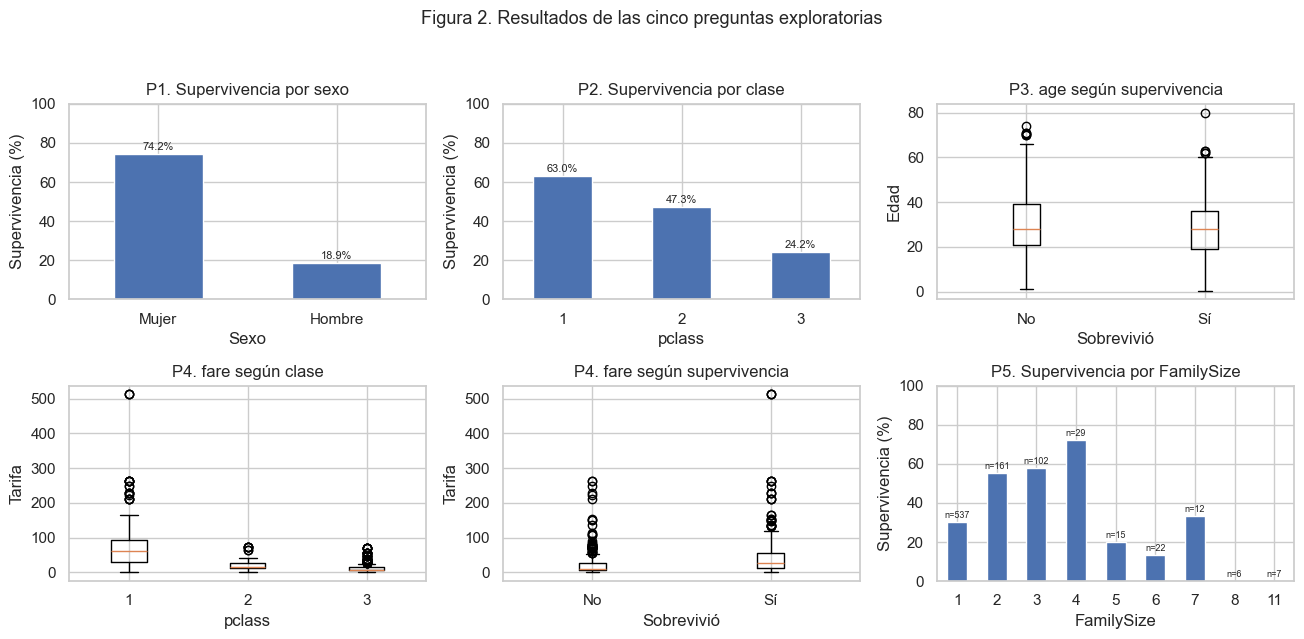

In [10]:
# Figura 2. Síntesis gráfica de las cinco preguntas exploratorias
fig, axes = plt.subplots(2, 3, figsize=(13.2, 6.5))

surv_sex["tasa_pct"].plot(kind="bar", ax=axes[0,0], rot=0)
axes[0,0].set_xticklabels(["Mujer", "Hombre"])
axes[0,0].set_title("P1. Supervivencia por sexo")
axes[0,0].set_ylabel("Supervivencia (%)")
axes[0,0].set_xlabel("Sexo")
axes[0,0].set_ylim(0, 100)
for i,v in enumerate(surv_sex["tasa_pct"].values):
    axes[0,0].text(i, v+2, f"{v:.1f}%", ha="center", fontsize=8)

surv_class["tasa_pct"].plot(kind="bar", ax=axes[0,1], rot=0)
axes[0,1].set_title("P2. Supervivencia por clase")
axes[0,1].set_ylabel("Supervivencia (%)")
axes[0,1].set_xlabel("pclass")
axes[0,1].set_ylim(0, 100)
for i,v in enumerate(surv_class["tasa_pct"].values):
    axes[0,1].text(i, v+2, f"{v:.1f}%", ha="center", fontsize=8)

age_groups = [titanic.loc[titanic['survived']==0,'age'].dropna(), titanic.loc[titanic['survived']==1,'age'].dropna()]
axes[0,2].boxplot(age_groups)
axes[0,2].set_xticks([1, 2])
axes[0,2].set_xticklabels(["No", "Sí"])
axes[0,2].set_title("P3. age según supervivencia")
axes[0,2].set_ylabel("Edad")
axes[0,2].set_xlabel("Sobrevivió")

fare_by_class = [titanic.loc[titanic['pclass']==cl,'fare'].dropna() for cl in [1,2,3]]
axes[1,0].boxplot(fare_by_class, showfliers=True)
axes[1,0].set_xticks([1, 2, 3])
axes[1,0].set_xticklabels(["1", "2", "3"])
axes[1,0].set_title("P4. fare según clase")
axes[1,0].set_ylabel("Tarifa")
axes[1,0].set_xlabel("pclass")

fare_by_surv = [titanic.loc[titanic['survived']==0,'fare'].dropna(), titanic.loc[titanic['survived']==1,'fare'].dropna()]
axes[1,1].boxplot(fare_by_surv, showfliers=True)
axes[1,1].set_xticks([1, 2])
axes[1,1].set_xticklabels(["No", "Sí"])
axes[1,1].set_title("P4. fare según supervivencia")
axes[1,1].set_ylabel("Tarifa")
axes[1,1].set_xlabel("Sobrevivió")

family["tasa_pct"].plot(kind="bar", ax=axes[1,2], rot=0)
axes[1,2].set_title("P5. Supervivencia por FamilySize")
axes[1,2].set_ylabel("Supervivencia (%)")
axes[1,2].set_xlabel("FamilySize")
axes[1,2].set_ylim(0, 100)
for i, (_,row) in enumerate(family.iterrows()):
    axes[1,2].text(i, row['tasa_pct']+2, f"n={int(row['n'])}", ha="center", fontsize=6.5)

fig.suptitle("Figura 2. Resultados de las cinco preguntas exploratorias", fontsize=13)
fig.tight_layout(rect=[0,0,1,0.95])
fig.savefig(FIGURES_DIR / "02_relaciones_preguntas_ejecutadas.png", dpi=180, bbox_inches="tight")
plt.show()


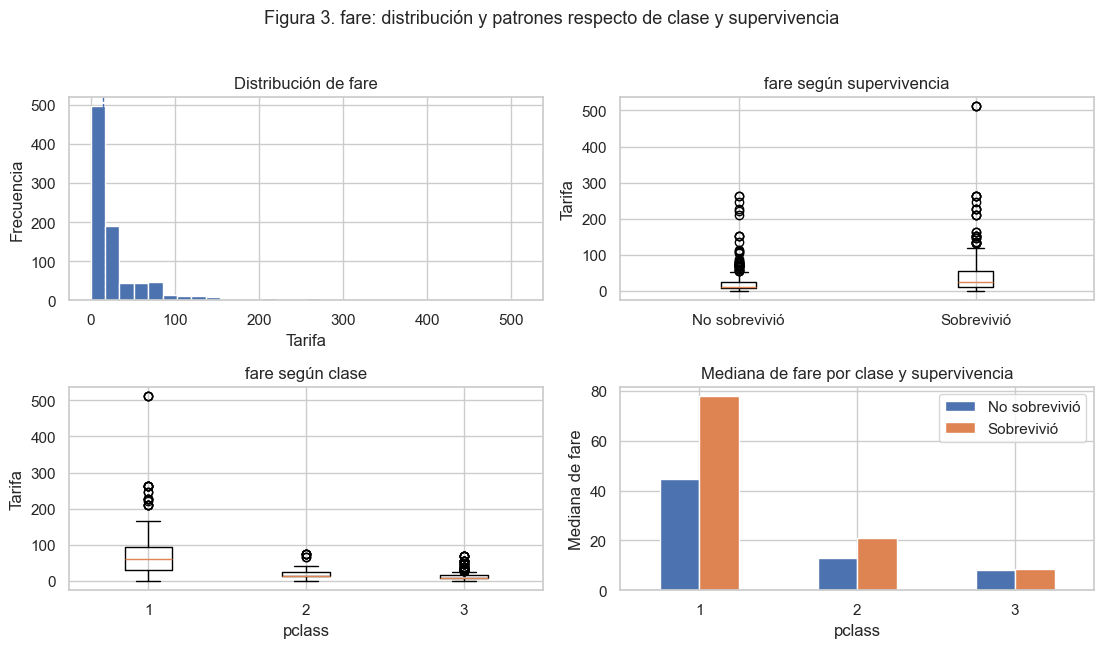

In [11]:
# Figura 3. Análisis de fare respecto de clase y supervivencia
fig, axes = plt.subplots(2, 2, figsize=(11.2, 6.6))

axes[0,0].hist(titanic["fare"].dropna(), bins=30)
axes[0,0].axvline(titanic["fare"].median(), linestyle="--", linewidth=1)
axes[0,0].set_title("Distribución de fare")
axes[0,0].set_xlabel("Tarifa")
axes[0,0].set_ylabel("Frecuencia")

fare_by_surv = [titanic.loc[titanic['survived']==0,'fare'].dropna(), titanic.loc[titanic['survived']==1,'fare'].dropna()]
axes[0,1].boxplot(fare_by_surv, showfliers=True)
axes[0,1].set_xticks([1, 2])
axes[0,1].set_xticklabels(["No sobrevivió", "Sobrevivió"])
axes[0,1].set_title("fare según supervivencia")
axes[0,1].set_ylabel("Tarifa")

fare_by_class = [titanic.loc[titanic['pclass']==c,'fare'].dropna() for c in [1,2,3]]
axes[1,0].boxplot(fare_by_class, showfliers=True)
axes[1,0].set_xticks([1, 2, 3])
axes[1,0].set_xticklabels(["1", "2", "3"])
axes[1,0].set_title("fare según clase")
axes[1,0].set_xlabel("pclass")
axes[1,0].set_ylabel("Tarifa")

pivot_median = titanic.pivot_table(index="pclass", columns="survived", values="fare", aggfunc="median")
pivot_median.columns = ["No sobrevivió", "Sobrevivió"]
pivot_median.plot(kind="bar", ax=axes[1,1], rot=0)
axes[1,1].set_title("Mediana de fare por clase y supervivencia")
axes[1,1].set_xlabel("pclass")
axes[1,1].set_ylabel("Mediana de fare")
axes[1,1].legend(title="")

fig.suptitle("Figura 3. fare: distribución y patrones respecto de clase y supervivencia", fontsize=13)
fig.tight_layout(rect=[0,0,1,0.96])
fig.savefig(FIGURES_DIR / "03_fare_clase_supervivencia.png", dpi=180, bbox_inches="tight")
plt.show()


## 5.2 Registro trazable de decisiones exploratorias
La siguiente tabla se construye durante la ejecución y documenta cada decisión, su justificación y el resultado intermedio efectivamente producido.

In [12]:

decisiones = pd.DataFrame([
    [
        "D1",
        "Utilizar una copia local auditada del dataset Titanic de Seaborn",
        "Evitar dependencias externas y asegurar identidad del insumo",
        f"SHA-256 verificado; entrada {raw.shape[0]} × {raw.shape[1]}"
    ],
    [
        "D2",
        "No imputar valores faltantes en esta fase",
        "Evitar introducir supuestos de tratamiento antes de completar el diagnóstico",
        f"Variables con faltantes documentadas: {int((calidad['nulos'] > 0).sum())}"
    ],
    [
        "D3",
        "Tratar pclass como variable ordinal categórica",
        "Sus valores representan categorías de clase y no una magnitud continua",
        "Comparaciones ejecutadas por categoría y en cruce con sex"
    ],
    [
        "D4",
        "Derivar FamilySize = sibsp + parch + 1",
        "Representar de forma reproducible el tamaño familiar registrado a bordo",
        f"FamilySize generada con {titanic['FamilySize'].nunique()} niveles observados"
    ],
    [
        "D5",
        "Derivar IsAlone como síntesis secundaria",
        "Comparar viajar solo frente a registrar al menos un familiar sin reemplazar FamilySize",
        f"IsAlone generada con {titanic['IsAlone'].nunique()} categorías"
    ],
    [
        "D6",
        "Conservar observaciones extremas de fare identificadas mediante IQR",
        "La condición estadística de valor extremo no demuestra por sí misma un error de registro",
        f"{fare_outliers_n} observaciones identificadas y conservadas"
    ],
    [
        "D7",
        "Conservar filas completamente coincidentes cuando no exista identificador individual único",
        "Evitar eliminar observaciones sin evidencia suficiente de duplicidad del mismo pasajero",
        f"{duplicados} filas completamente coincidentes documentadas y conservadas"
    ],
], columns=["ID", "Decisión", "Motivo", "Resultado intermedio"])

display(decisiones)
decisiones.to_csv(OUTPUTS_DIR / "decisiones_exploratorias.csv", index=False, encoding="utf-8")


,ID,Decisión,Motivo,Resultado intermedio
0,D1,Utilizar una copia local auditada del dataset ...,Evitar dependencias externas y asegurar identi...,SHA-256 verificado; entrada 891 × 15
1,D2,No imputar valores faltantes en esta fase,Evitar introducir supuestos de tratamiento ant...,Variables con faltantes documentadas: 4
2,D3,Tratar pclass como variable ordinal categórica,Sus valores representan categorías de clase y ...,Comparaciones ejecutadas por categoría y en cr...
3,D4,Derivar FamilySize = sibsp + parch + 1,Representar de forma reproducible el tamaño fa...,FamilySize generada con 9 niveles observados
4,D5,Derivar IsAlone como síntesis secundaria,Comparar viajar solo frente a registrar al men...,IsAlone generada con 2 categorías
5,D6,Conservar observaciones extremas de fare ident...,La condición estadística de valor extremo no d...,116 observaciones identificadas y conservadas
6,D7,Conservar filas completamente coincidentes cua...,Evitar eliminar observaciones sin evidencia su...,107 filas completamente coincidentes documenta...


# VI. Resultados e interpretación inicial
La matriz siguiente se genera a partir de las variables calculadas en la corrida y vincula cada pregunta con la acción ejecutada, el resultado obtenido y su evidencia.

In [13]:

resultado_p1 = (
    f"Supervivencia global {surv_global:.1f} %; "
    + "; ".join(
        f"{etiqueta_sexo.get(idx, idx)} {row['tasa_pct']:.1f} %" for idx, row in surv_sex.iterrows()
    )
)
resultado_p2 = "; ".join(
    f"clase {idx} {row['tasa_pct']:.1f} %" for idx, row in surv_class.sort_index().iterrows()
)
resultado_p3 = (
    f"age: {age_validos} válidos, {age_faltantes} faltantes ({age_faltantes_pct:.1f} %); "
    f"medianas {mediana_age_0:.1f} y {mediana_age_1:.1f} años"
)
resultado_p4 = (
    f"fare: mediana {titanic['fare'].median():.2f}; asimetría {fare_skew:.2f}; "
    f"{fare_outliers_n} casos fuera de límites IQR; medianas por pclass: "
    + "/".join(f"{fare_class.loc[c, 'mediana']:.2f}" for c in sorted(fare_class.index))
)
resultado_p5 = (
    f"Solo {solo_rate:.1f} %; con familiares {acom_rate:.1f} %; "
    f"FamilySize con mayor tasa observada: {family_max_idx} ({family_max_rate:.1f} %, n={family_max_n})"
)

resultados = pd.DataFrame([
    ["P1", "Tasa global y comparación por sex", resultado_p1, "Bloque P1; Figuras 1 y 2; supervivencia_por_sexo.csv"],
    ["P2", "Tasas por pclass y cruce sex × pclass", resultado_p2, "Bloque P2; Figura 2; supervivencia_por_clase.csv; supervivencia_sexo_clase.csv"],
    ["P3", "Descriptivos de age y comparación por supervivencia", resultado_p3, "Bloque P3; Figuras 1 y 2; age_por_supervivencia.csv"],
    ["P4", "Distribución de fare, IQR y cruces con pclass/survived", resultado_p4, "Bloque P4; Figuras 1 y 3; fare_por_supervivencia.csv; fare_por_clase.csv; fare_por_clase_y_supervivencia.csv; revision_outliers_fare_iqr.csv"],
    ["P5", "FamilySize e IsAlone con tasas y tamaños de grupo", resultado_p5, "Bloque P5; Figura 2; supervivencia_por_tamano_familiar.csv; supervivencia_solo_vs_acompanado.csv"],
], columns=["Pregunta", "Acción ejecutada", "Resultado obtenido", "Evidencia"])

display(resultados)
resultados.to_csv(OUTPUTS_DIR / "tabla_pregunta_accion_resultado.csv", index=False, encoding="utf-8")


,Pregunta,Acción ejecutada,Resultado obtenido,Evidencia
0,P1,Tasa global y comparación por sex,Supervivencia global 38.4 %; mujeres 74.2 %; h...,Bloque P1; Figuras 1 y 2; supervivencia_por_se...
1,P2,Tasas por pclass y cruce sex × pclass,clase 1 63.0 %; clase 2 47.3 %; clase 3 24.2 %,Bloque P2; Figura 2; supervivencia_por_clase.c...
2,P3,Descriptivos de age y comparación por superviv...,"age: 714 válidos, 177 faltantes (19.9 %); medi...",Bloque P3; Figuras 1 y 2; age_por_supervivenci...
3,P4,"Distribución de fare, IQR y cruces con pclass/...",fare: mediana 14.45; asimetría 4.79; 116 casos...,Bloque P4; Figuras 1 y 3; fare_por_supervivenc...
4,P5,FamilySize e IsAlone con tasas y tamaños de grupo,Solo 30.4 %; con familiares 50.6 %; FamilySize...,Bloque P5; Figura 2; supervivencia_por_tamano_...


In [14]:

orden_sexo = surv_sex["tasa_pct"].sort_values(ascending=False)
orden_clase = surv_class["tasa_pct"].sort_values(ascending=False)

deck_n = int(titanic["deck"].isna().sum())
deck_pct = float(titanic["deck"].isna().mean() * 100)

sintesis = [
    f"La supervivencia global observada fue {surv_global:.1f} %. La mayor tasa por sexo correspondió a {etiqueta_sexo.get(orden_sexo.index[0], orden_sexo.index[0])} ({orden_sexo.iloc[0]:.1f} %) y la menor a {etiqueta_sexo.get(orden_sexo.index[-1], orden_sexo.index[-1])} ({orden_sexo.iloc[-1]:.1f} %).",
    f"Por clase, la mayor tasa observada correspondió a pclass={orden_clase.index[0]} ({orden_clase.iloc[0]:.1f} %) y la menor a pclass={orden_clase.index[-1]} ({orden_clase.iloc[-1]:.1f} %). El cruce con sex se conserva como contexto descriptivo.",
    f"En age se observaron {age_faltantes} valores faltantes ({age_faltantes_pct:.1f} %); las medianas por supervivencia fueron {mediana_age_0:.1f} y {mediana_age_1:.1f} años.",
    f"fare presentó una asimetría de {fare_skew:.2f}; la regla IQR identificó {fare_outliers_n} observaciones fuera de límites. Los resultados por fare se interpretan junto con pclass.",
    f"Para FamilySize, el grupo con mayor tasa observada fue {family_max_idx} ({family_max_rate:.1f} %, n={family_max_n}). La comparación solo/acompañado fue {solo_rate:.1f} % frente a {acom_rate:.1f} %.",
    f"deck registró {deck_n} valores faltantes ({deck_pct:.1f} %), condición que limita su utilidad en este primer análisis."
]

display(Markdown("### Síntesis generada a partir de la ejecución\n" + "\n".join(f"{i+1}. {texto}" for i, texto in enumerate(sintesis))))


### Síntesis generada a partir de la ejecución
1. La supervivencia global observada fue 38.4 %. La mayor tasa por sexo correspondió a mujeres (74.2 %) y la menor a hombres (18.9 %).
2. Por clase, la mayor tasa observada correspondió a pclass=1 (63.0 %) y la menor a pclass=3 (24.2 %). El cruce con sex se conserva como contexto descriptivo.
3. En age se observaron 177 valores faltantes (19.9 %); las medianas por supervivencia fueron 28.0 y 28.0 años.
4. fare presentó una asimetría de 4.79; la regla IQR identificó 116 observaciones fuera de límites. Los resultados por fare se interpretan junto con pclass.
5. Para FamilySize, el grupo con mayor tasa observada fue 4 (72.4 %, n=29). La comparación solo/acompañado fue 30.4 % frente a 50.6 %.
6. deck registró 688 valores faltantes (77.2 %), condición que limita su utilidad en este primer análisis.

# VII. Supuestos y limitaciones
### Supuestos de interpretación
- Cada fila corresponde a un registro del dataset `titanic` distribuido por Seaborn.
- `survived` se interpreta como 0 = no sobrevivió y 1 = sobrevivió.
- `pclass` representa la clase del pasajero y se trata como variable ordinal categórica.
- `sex`, `age`, `fare`, `sibsp` y `parch` se emplean de acuerdo con la definición del conjunto de datos.
- `FamilySize = sibsp + parch + 1` se utiliza como aproximación al tamaño familiar registrado a bordo.

Las limitaciones cuantitativas se generan a continuación a partir de la ejecución.

In [15]:

limitaciones = [
    f"`age` presenta {age_faltantes} valores faltantes ({age_faltantes_pct:.1f} %); sus comparaciones se realizan con observaciones válidas.",
    f"`deck` presenta {deck_n} valores faltantes ({deck_pct:.1f} %), por lo que no se utiliza para sustentar hallazgos principales en esta fase.",
    f"La regla IQR identifica {fare_outliers_n} observaciones extremas en `fare`; se conservan y se documentan sin asumir que sean errores.",
    f"Se identifican {duplicados} filas completamente coincidentes en las variables disponibles; sin un identificador individual único no se eliminan automáticamente.",
    "Las asociaciones reportadas son descriptivas y no establecen causalidad ni generalización inferencial."
]
display(Markdown("### Limitaciones observadas en la ejecución\n" + "\n".join(f"- {x}" for x in limitaciones)))


### Limitaciones observadas en la ejecución
- `age` presenta 177 valores faltantes (19.9 %); sus comparaciones se realizan con observaciones válidas.
- `deck` presenta 688 valores faltantes (77.2 %), por lo que no se utiliza para sustentar hallazgos principales en esta fase.
- La regla IQR identifica 116 observaciones extremas en `fare`; se conservan y se documentan sin asumir que sean errores.
- Se identifican 107 filas completamente coincidentes en las variables disponibles; sin un identificador individual único no se eliminan automáticamente.
- Las asociaciones reportadas son descriptivas y no establecen causalidad ni generalización inferencial.

### Continuidad del análisis
Las decisiones de imputación, tratamiento definitivo de ausencias, selección de variables y eventual análisis inferencial o predictivo deberán justificarse en fases posteriores de acuerdo con el alcance metodológico del proyecto.

## 7.1 Registro de reproducibilidad
Se documentan la identidad del archivo de entrada, dimensiones, transformaciones y versiones del entorno utilizado. A partir de los resultados calculados se genera además una síntesis técnica reutilizable para el informe complementario.

In [16]:
manifest = "\n".join([
    f"fecha_hora_ejecucion={datetime.now().astimezone().isoformat(timespec='seconds')}",
    f"fuente={fuente_datos}",
    f"archivo_entrada_local={DATA_PATH.relative_to(BASE_DIR).as_posix()}",
    f"sha256={sha256}",
    f"sha256_esperado={EXPECTED_SHA256}",
    f"integridad_hash={'OK' if sha256 == EXPECTED_SHA256 else 'ERROR'}",
    f"filas_entrada={raw.shape[0]}",
    f"columnas_entrada={raw.shape[1]}",
    f"filas_coincidentes_completas={duplicados}",
    f"archivo_procesado={(PROCESS_DIR/'titanic_eda_process.csv').relative_to(BASE_DIR).as_posix()}",
    f"filas_procesadas={titanic.shape[0]}",
    f"columnas_procesadas={titanic.shape[1]}",
    f"python={sys.version.split()[0]}",
    f"pandas={pd.__version__}",
    f"numpy={np.__version__}",
    f"seaborn={sns.__version__}",
    f"matplotlib={plt.matplotlib.__version__}",
    f"ipykernel={version_paquete('ipykernel')}",
    f"notebook={version_paquete('notebook')}",
    f"jupyterlab={version_paquete('jupyterlab')}",
])
(OUTPUTS_DIR / "manifest_ejecucion.txt").write_text(manifest, encoding="utf-8")

resumen = f"""# Resumen EDA - Sumativa S01

## Identidad de la ejecución
- Fuente: dataset `titanic` de Seaborn mediante copia local auditada.
- SHA-256: `{sha256}`.
- Entrada: {raw.shape[0]} filas × {raw.shape[1]} columnas.
- Procesado: {titanic.shape[0]} filas × {titanic.shape[1]} columnas.

## Resultados principales
- Supervivencia global: {surv_global:.1f}%.
- Mujeres: {surv_sex.loc['female','tasa_pct']:.1f}%.
- Hombres: {surv_sex.loc['male','tasa_pct']:.1f}%.
- pclass 1/2/3: {surv_class.loc[1,'tasa_pct']:.1f}% / {surv_class.loc[2,'tasa_pct']:.1f}% / {surv_class.loc[3,'tasa_pct']:.1f}%.
- `age` faltantes: {titanic['age'].isna().sum()} ({titanic['age'].isna().mean()*100:.1f}%).
- `deck` faltantes: {titanic['deck'].isna().sum()} ({titanic['deck'].isna().mean()*100:.1f}%).
- Mediana de `age`: {age_stats.loc[0,'mediana']:.0f} años en no sobrevivientes y {age_stats.loc[1,'mediana']:.0f} años en sobrevivientes.
- Mediana global de `fare`: {titanic['fare'].median():.2f}.
- Límite superior IQR de `fare`: {high:.2f}.
- `fare` fuera de límites IQR: {int(fare_outliers.sum())} observaciones.
- Mediana de `fare` por pclass 1/2/3: {fare_class.loc[1,'mediana']:.2f} / {fare_class.loc[2,'mediana']:.2f} / {fare_class.loc[3,'mediana']:.2f}.
- Supervivencia viajando solo: {alone.loc[1,'tasa_pct']:.1f}%.
- Supervivencia con familiares: {alone.loc[0,'tasa_pct']:.1f}%.

## Decisiones metodológicas
- No se imputan faltantes en S01.
- No se eliminan automáticamente valores extremos de `fare`.
- No se eliminan automáticamente las {duplicados} filas completamente coincidentes por ausencia de un identificador individual único.
- Las asociaciones son descriptivas y no se interpretan causalmente.
"""
(OUTPUTS_DIR / "resumen_eda.md").write_text(resumen, encoding="utf-8")
(OUTPUTS_DIR / "resumen_para_informe.md").write_text(resumen, encoding="utf-8")
print(manifest)

fecha_hora_ejecucion=2026-09-06T12:59:21-03:00
fuente=Copia local auditada del dataset Titanic distribuido por Seaborn
archivo_entrada_local=data/input/titanic_seaborn.csv
sha256=43af81a01f25a7771c9a42809a31625f4d0de3f335cdf29961f9ba179a86c13d
sha256_esperado=43af81a01f25a7771c9a42809a31625f4d0de3f335cdf29961f9ba179a86c13d
integridad_hash=OK
filas_entrada=891
columnas_entrada=15
filas_coincidentes_completas=107
archivo_procesado=data/process/titanic_eda_process.csv
filas_procesadas=891
columnas_procesadas=17
python=3.12.4
pandas=2.2.2
numpy=1.26.4
seaborn=0.13.2
matplotlib=3.8.4
ipykernel=6.28.0
notebook=7.0.8
jupyterlab=4.0.11


## 7.2 Validación de coherencia de la ejecución
La validación final comprueba integridad de la entrada, conservación de registros, consistencia de las transformaciones, concordancia entre cálculos y archivos exportados, y existencia de los productos derivados. No compara los resultados exploratorios contra valores preestablecidos.

In [17]:

archivos_esperados = [
    PROCESS_DIR / "titanic_eda_process.csv",
    FIGURES_DIR / "01_diagnostico_calidad_distribuciones.png",
    FIGURES_DIR / "02_relaciones_preguntas_ejecutadas.png",
    FIGURES_DIR / "03_fare_clase_supervivencia.png",
    OUTPUTS_DIR / "resumen_calidad.csv",
    OUTPUTS_DIR / "rangos_numericos.csv",
    OUTPUTS_DIR / "categorias_observadas.csv",
    OUTPUTS_DIR / "supervivencia_por_sexo.csv",
    OUTPUTS_DIR / "supervivencia_por_clase.csv",
    OUTPUTS_DIR / "supervivencia_sexo_clase.csv",
    OUTPUTS_DIR / "age_por_supervivencia.csv",
    OUTPUTS_DIR / "fare_por_supervivencia.csv",
    OUTPUTS_DIR / "fare_por_clase.csv",
    OUTPUTS_DIR / "fare_por_clase_y_supervivencia.csv",
    OUTPUTS_DIR / "revision_outliers_fare_iqr.csv",
    OUTPUTS_DIR / "supervivencia_por_tamano_familiar.csv",
    OUTPUTS_DIR / "supervivencia_solo_vs_acompanado.csv",
    OUTPUTS_DIR / "decisiones_exploratorias.csv",
    OUTPUTS_DIR / "tabla_pregunta_accion_resultado.csv",
    OUTPUTS_DIR / "manifest_ejecucion.txt",
    OUTPUTS_DIR / "resumen_eda.md",
    OUTPUTS_DIR / "resumen_para_informe.md",
]

procesado_releido = pd.read_csv(PROCESS_DIR / "titanic_eda_process.csv")
revision_iqr = pd.read_csv(OUTPUTS_DIR / "revision_outliers_fare_iqr.csv")
sexo_exportado = pd.read_csv(OUTPUTS_DIR / "supervivencia_por_sexo.csv", index_col=0)
clase_exportada = pd.read_csv(OUTPUTS_DIR / "supervivencia_por_clase.csv", index_col=0)

columnas_originales_conservadas = procesado_releido[list(raw.columns)].equals(raw.reset_index(drop=True))
sexo_exportado_consistente = np.allclose(
    sexo_exportado.loc[surv_sex.index, "tasa_pct"].to_numpy(),
    surv_sex["tasa_pct"].to_numpy(),
    equal_nan=True,
)
clase_exportada_consistente = np.allclose(
    clase_exportada.loc[surv_class.index, "tasa_pct"].to_numpy(),
    surv_class["tasa_pct"].to_numpy(),
    equal_nan=True,
)

checks = {
    "integridad_hash_entrada": sha256 == EXPECTED_SHA256,
    "dimensiones_entrada": tuple(raw.shape) == EXPECTED_INPUT_SHAPE,
    "filas_procesadas_conservadas": len(titanic) == len(raw),
    "columnas_derivadas_agregadas": titanic.shape[1] == raw.shape[1] + 2,
    "FamilySize_consistente": bool((titanic["FamilySize"] == titanic["sibsp"] + titanic["parch"] + 1).all()),
    "IsAlone_consistente": bool((titanic["IsAlone"] == (titanic["FamilySize"] == 1).astype(int)).all()),
    "archivo_procesado_reproducible": tuple(procesado_releido.shape) == tuple(titanic.shape),
    "columnas_originales_conservadas": bool(columnas_originales_conservadas),
    "supervivencia_sexo_exportada_consistente": bool(sexo_exportado_consistente),
    "supervivencia_clase_exportada_consistente": bool(clase_exportada_consistente),
    "conteos_sexo_consistentes": int(surv_sex["n"].sum()) == len(titanic),
    "conteos_clase_consistentes": int(surv_class["n"].sum()) == len(titanic),
    "conteos_age_consistentes": int(age_stats["n"].sum()) == int(titanic["age"].notna().sum()),
    "conteos_family_consistentes": int(family["n"].sum()) == len(titanic),
    "conteos_IsAlone_consistentes": int(alone["n"].sum()) == len(titanic),
    "IQR_exportado_consistente": int(revision_iqr.loc[0, "casos_fuera_iqr"]) == fare_outliers_n,
    "archivos_derivados_generados": all(p.exists() for p in archivos_esperados),
}

faltantes_archivos = [p.relative_to(BASE_DIR).as_posix() for p in archivos_esperados if not p.exists()]
lineas = [f"{nombre}={'OK' if estado else 'ERROR'}" for nombre, estado in checks.items()]
if faltantes_archivos:
    lineas.append("archivos_faltantes=" + " | ".join(faltantes_archivos))

estado_global = all(checks.values())
lineas.append(f"estado_global={'OK' if estado_global else 'ERROR'}")
(OUTPUTS_DIR / "validacion_final.txt").write_text("\n".join(lineas), encoding="utf-8")

if not estado_global:
    errores = [nombre for nombre, estado in checks.items() if not estado]
    raise AssertionError("Falló la validación final: " + ", ".join(errores))

cierre = (
    "La ejecución completó la carga auditada, el diagnóstico de calidad, las cinco preguntas exploratorias, "
    "las transformaciones derivadas, la generación de figuras y tablas, y la validación de coherencia interna. "
    "Los resultados quedan documentados en el notebook y en los archivos de `outputs/`, mientras que el dataset de entrada "
    "permanece inalterado. Las fases posteriores podrán profundizar tratamientos de faltantes, análisis inferencial o modelamiento "
    "según el alcance metodológico que corresponda."
)
display(Markdown("# VIII. Cierre del avance\n" + cierre))
print("VALIDACIÓN FINAL: OK")
print(f"Archivos derivados verificados: {len(archivos_esperados)}")


# VIII. Cierre del avance
La ejecución completó la carga auditada, el diagnóstico de calidad, las cinco preguntas exploratorias, las transformaciones derivadas, la generación de figuras y tablas, y la validación de coherencia interna. Los resultados quedan documentados en el notebook y en los archivos de `outputs/`, mientras que el dataset de entrada permanece inalterado. Las fases posteriores podrán profundizar tratamientos de faltantes, análisis inferencial o modelamiento según el alcance metodológico que corresponda.

VALIDACIÓN FINAL: OK
Archivos derivados verificados: 22
